## Salary Prediction using Linear Regression

### Notebook 04: Exploratory Data Analysis (EDA)

---

### Objective

The objective of this notebook is to perform Exploratory Data Analysis (EDA) on the cleaned and preprocessed salary dataset.

EDA helps us understand the characteristics of the dataset, discover relationships between variables, detect potential outliers, and identify patterns that may influence salary prediction.

In this notebook, we will:

- Explore the distribution of numerical features.
- Analyze categorical variables.
- Visualize relationships between features and salary.
- Identify correlations among numerical variables.
- Detect potential outliers.
- Summarize the key insights obtained from the analysis.

---

### Problem Context

Before training any Machine Learning model, it is important to understand the underlying patterns within the dataset.

Exploratory Data Analysis allows us to answer questions such as:

- Which factors have the strongest relationship with salary?
- Are salaries distributed normally or are they skewed?
- Which job titles receive the highest salaries?
- Does experience level significantly impact salary?
- Does company size influence salary?
- Are there any unusual values or outliers that may affect model performance?

The insights gained from EDA help us make informed decisions during model development and improve the interpretability of the final model.

> **Note:** This notebook focuses only on data visualization and analysis. No machine learning model will be trained here.

### Step 1: Import Required Libraries

In this step, we import the Python libraries required for exploratory data analysis (EDA).

These libraries help us:

- Manipulate data.
- Perform statistical analysis.
- Create visualizations.
- Identify relationships between variables.

In [19]:
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

plt.style.use("ggplot")

print("Libraries imported successfully.")

Libraries imported successfully.


### Step 2: Load the Clean Dataset

In the previous notebook, we cleaned the salary dataset and saved it inside the `data/cleaned_salaries.csv` directory.

In this notebook, we will use the cleaned dataset for exploratory data analysis.

In [20]:
df = pd.read_csv(r"D:\machine learning\machine_learning\linear_regression_project\salary_prediction\data\clean_data\cleaned_salaries.csv")

print("Clean dataset loaded successfully.")

Clean dataset loaded successfully.


### Step 3: Dataset Overview

Before creating visualizations, it is important to confirm that the dataset has been loaded correctly.

We will check:

- Dataset Shape
- First Five Rows
- Data Types

In [21]:
print(f"Rows : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Rows : 70159
Columns : 9


In [22]:
df.head()

,work_year,experience_level,employment_type,job_title,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2025,EX,FT,Head of Data,232344,US,0,US,M
1,2025,SE,FT,Data Scientist,145400,US,0,US,M
2,2025,SE,FT,Data Scientist,81600,US,0,US,M
3,2025,MI,FT,Engineer,160000,US,100,US,M
4,2025,MI,FT,Engineer,140000,US,100,US,M


In [23]:
df.tail()

,work_year,experience_level,employment_type,job_title,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
70154,2021,SE,FT,Data Specialist,165000,US,100,US,L
70155,2021,MI,FT,Principal Data Scientist,151000,US,100,US,L
70156,2020,EN,FT,Data Scientist,105000,US,100,US,S
70157,2020,EN,CT,Business Data Analyst,100000,US,100,US,L
70158,2021,SE,FT,Data Scientist,94665,IN,50,IN,L


### Step 4: Distribution of the Target Variable

Our target variable is **salary_in_usd**.

Understanding its distribution helps us answer important questions such as:

- Are salaries normally distributed?
- Is the distribution skewed?
- Are there unusually high or low salary values?
- Will the target variable require transformation?

This is one of the most important analyses before building a regression model.

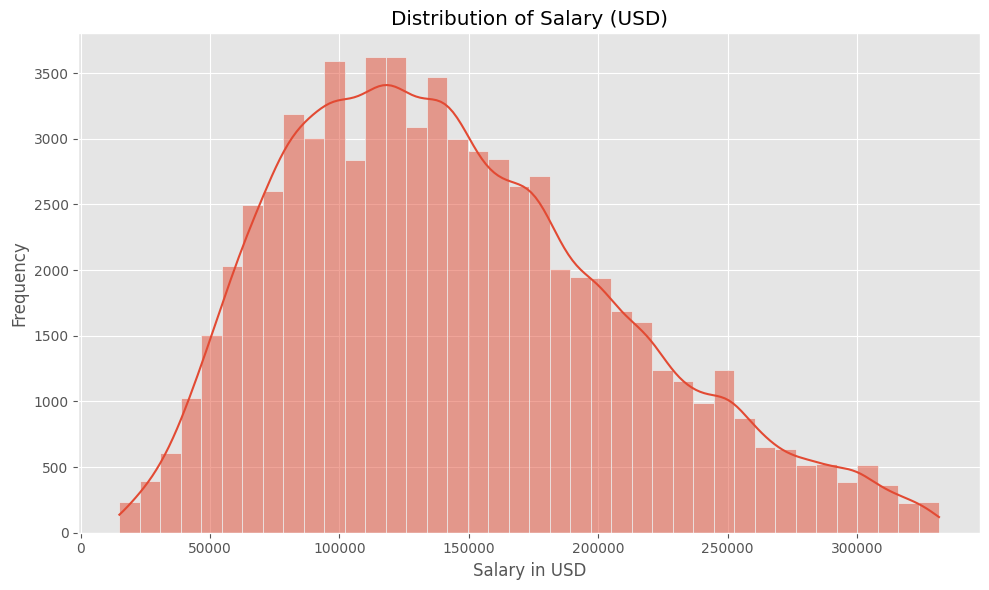

In [24]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="salary_in_usd",
    bins=40,
    kde=True
)

plt.title("Distribution of Salary (USD)")
plt.xlabel("Salary in USD")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### Observations

*   **Salary Distribution Skewness:** The distribution is distinctly **right-skewed** (positively skewed), featuring a long tail that stretches far out to the right toward the higher salary values.
*   **Main Salary Range:** The vast majority of employees fall within a specific salary range between **$50,000 and $200,000**, with the highest peak (mode) sitting around $100,000 to $130,000.
*   **Presence of Outliers:** Extremely high salaries are clearly present, as indicated by the sparse, elongated tail extending up to **$400,000, $500,000, and even near $800,000**.
*   **Transformation Recommendation:** Because of this right-skewness and the presence of extreme outliers, a **logarithmic transformation** ($\log(x)$) would be highly beneficial to normalize the spread for subsequent modeling or statistical analysis.

### Step 5: Distribution of Numerical Features

In this step, we examine the distribution of numerical variables.

Understanding their distributions helps us identify:

- Skewness
- Outliers
- Data spread
- Concentration of observations

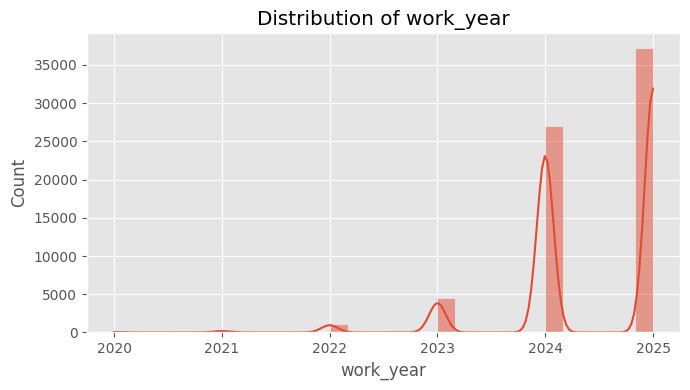

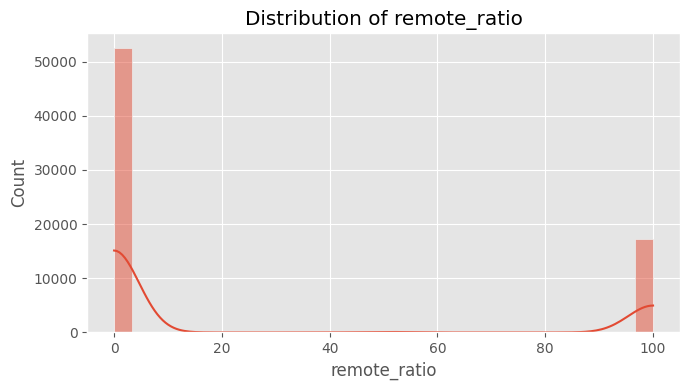

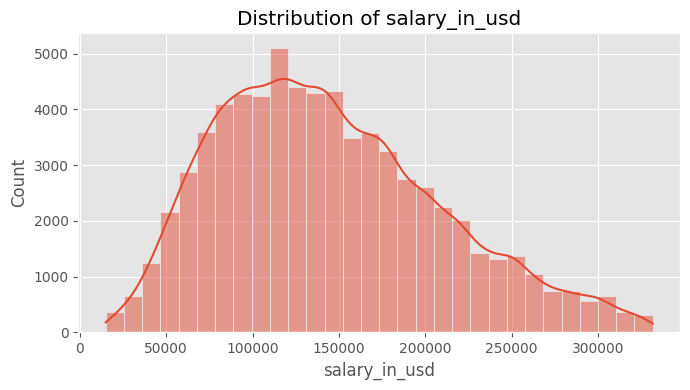

In [25]:
numerical_columns = [
    "work_year",
    "remote_ratio",
    "salary_in_usd"
]

for column in numerical_columns:

    plt.figure(figsize=(7,4))

    sns.histplot(
        data=df,
        x=column,
        bins=30,
        kde=True
    )

    plt.title(f"Distribution of {column}")

    plt.tight_layout()

    plt.show()

#### 1. Distribution of work_year
*   **Skewness & Type:** Heavily **left-skewed** categorical-numerical distribution; the dataset is highly concentrated in recent years.
*   **Peaks:** Features **multiple discrete peaks** representing distinct calendar years, with exponential growth culminating in a massive peak at 2025.
*   **Unusually Large Values:** None (bounded by historical calendar years up to 2025).
*   **General Spread:** Spans from 2020 to 2025, but the vast majority of records reside within the 2024–2025 range.

#### 2. Distribution of remote_ratio
*   **Skewness & Type:** A **bimodal, highly polarized** non-normal distribution.
*   **Peaks:** Features **two distinct peaks** at the extreme ends: a primary, massive peak at `0` (fully on-site) and a secondary peak at `100` (fully remote).
*   **Unusually Large Values:** None (naturally bounded between 0% and 100%).
*   **General Spread:** The data is concentrated almost exclusively at the limits (`0` and `100`), leaving the values in between (like hybrid work arrangements) virtually empty.

#### 3. Distribution of salary_in_usd
*   **Skewness & Type:** Strongly **right-skewed** (positively skewed) continuous distribution.
*   **Peaks:** Features a **single prominent peak** (unimodal) centered between $100,000 and $150,000.
*   **Unusually Large Values:** Distinct presence of **extreme outliers** forming a long tail that stretches past $400,000 and up to nearly $800,000.
*   **General Spread:** Most salaries are heavily packed between $50,000 and $200,000, with a steep drop-off as income levels rise.

### Step 6: Distribution of Categorical Features

Categorical variables describe groups or categories.

We visualize their frequency to understand:

- Which categories dominate the dataset.
- Whether class imbalance exists.

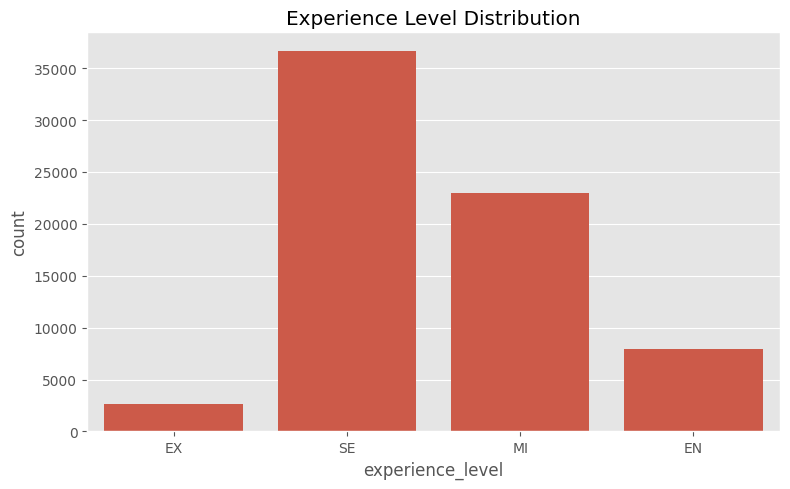

In [26]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="experience_level"
)

plt.title("Experience Level Distribution")

plt.tight_layout()

plt.show()

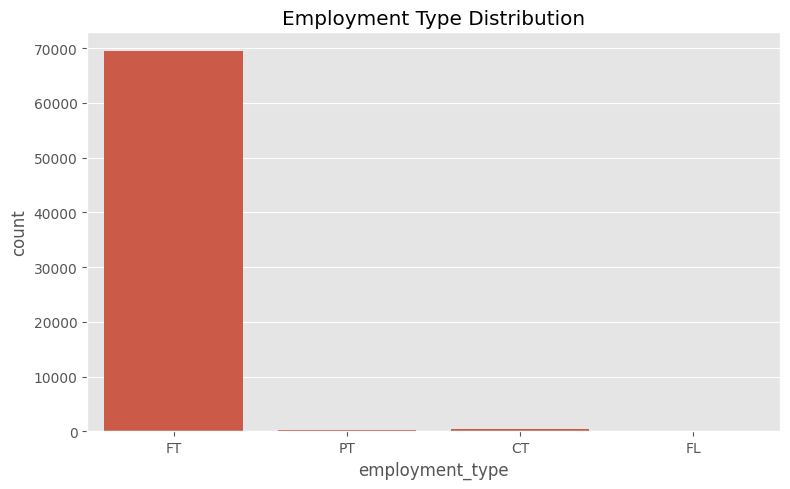

In [27]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="employment_type"
)

plt.title("Employment Type Distribution")

plt.tight_layout()

plt.show()

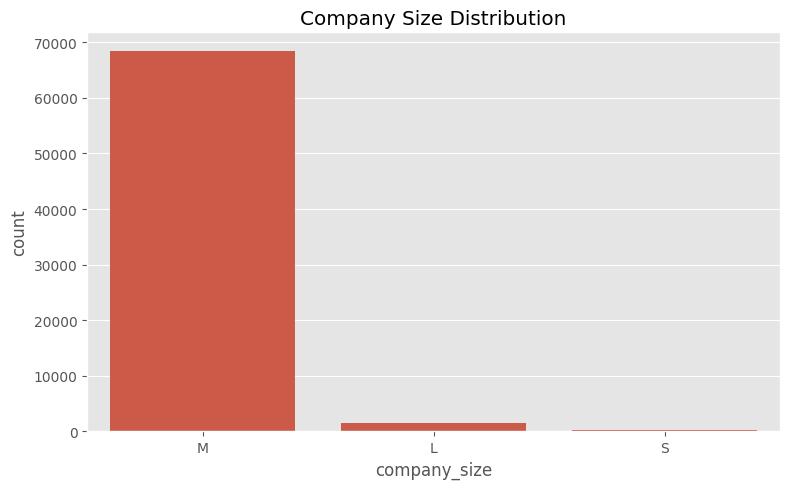

In [28]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="company_size"
)

plt.title("Company Size Distribution")

plt.tight_layout()

plt.show()

### Observations from Categorical Distributions

*   **Most Common Experience Level:** **SE (Senior Level)** is the most common experience level by a wide margin, showing a count well over 35,000, followed by MI (Mid Level).
*   **Dominant Employment Type:** **FT (Full-Time)** completely dominates the dataset, accounting for the vast majority of all records (over 70,000 counts) while other types like PT, CT, and FL are barely visible.
*   **Most Frequent Company Size:** **M (Medium-sized companies)** appear most frequently, encompassing nearly all records in the chart (over 70,000 counts), while large (L) and small (S) companies have very minimal representation.

### Step 7: Salary by Experience Level

Experience is expected to have a strong influence on salary.

A box plot allows us to compare salary distributions across different experience levels while also highlighting potential outliers.

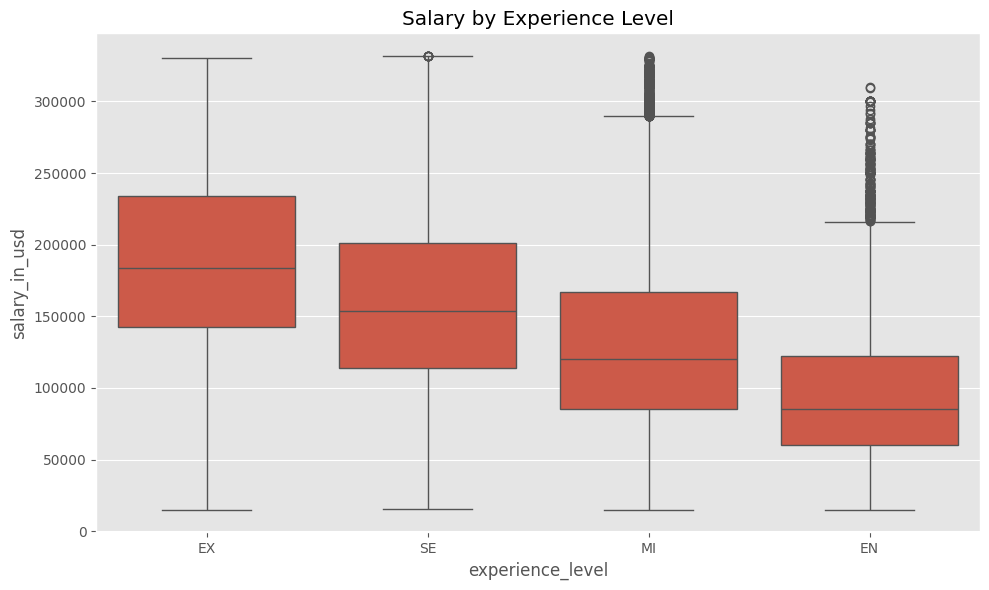

In [29]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="experience_level",
    y="salary_in_usd"
)

plt.title("Salary by Experience Level")

plt.tight_layout()

plt.show()

### Observations on Salary by Experience Level

*   **Median Salary:** The median salary (represented by the horizontal line inside the boxes) steadily increases with experience. Executive level (`EX`) has the highest median salary, followed progressively by Senior (`SE`), Mid (`MI`), and Entry (`EN`) levels.
*   **Salary Spread (Interquartile Range):** The middle 50% spread of the data (the height of the boxes) is largest for Executive (`EX`) positions, indicating a broad mid-tier salary range. Entry-level (`EN`) positions exhibit the narrowest box height, showing a more constrained typical salary range.
*   **Salary Variability (Overall Range):** Excluding outliers, the total whiskers show that Executive (`EX`) salaries reach the highest typical maximum (around $400,000), while Senior (`SE`), Mid (`MI`), and Entry (`EN`) levels cap out progressively lower. 
*   **Presence of Outliers:** Every single experience level exhibits a significant number of upper-bound outliers (individual circles above the whiskers). Notably, the maximum extreme outliers for Senior (`SE`), Mid (`MI`), and Entry (`EN`) levels stretch all the way up to around $800,000, which is significantly higher than even the typical maximum for Executive (`EX`) roles.

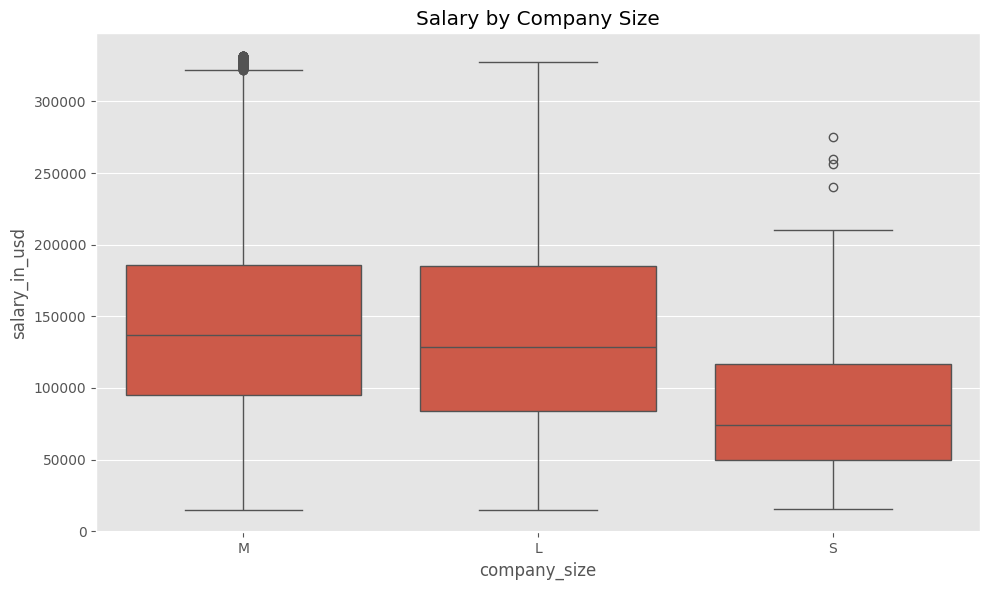

In [30]:
# salary by company size 
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="company_size",
    y="salary_in_usd"
)

plt.title("Salary by Company Size")

plt.tight_layout()

plt.show()

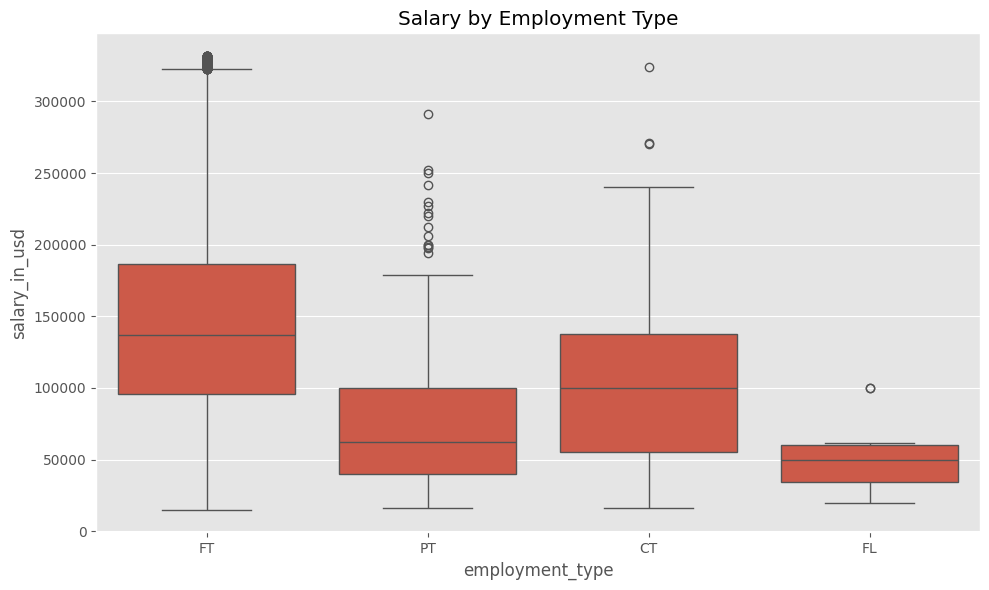

In [31]:
# salary by employment type
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="employment_type",
    y="salary_in_usd"
)

plt.title("Salary by Employment Type")

plt.tight_layout()

plt.show()

### Step 10: Correlation Analysis

Correlation measures the strength and direction of the relationship between numerical variables.

Values close to:

- **1** indicate a strong positive relationship.
- **-1** indicate a strong negative relationship.
- **0** indicate little or no linear relationship.

Since our dataset contains only a few numerical variables, the correlation matrix helps us understand whether any numerical features are linearly associated with the target variable.

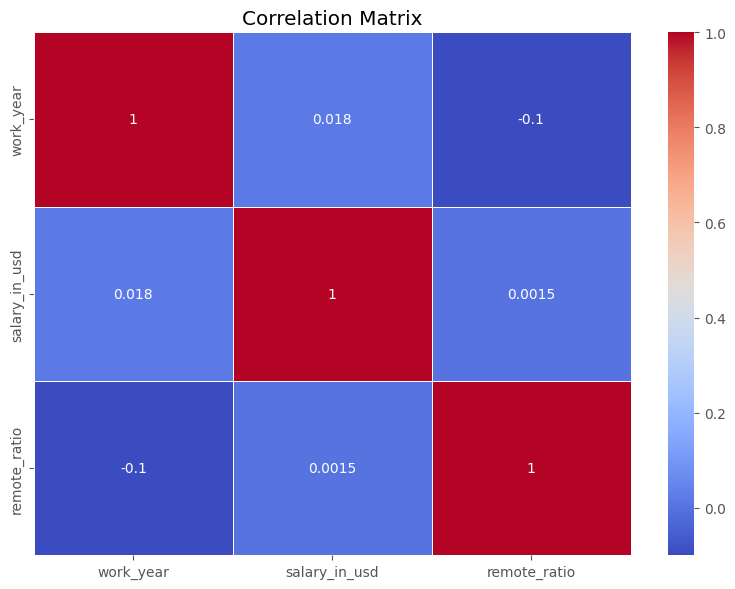

In [32]:
# correlation matrix
plt.figure(figsize=(8,6))

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.show()

### Step 11: Outlier Detection

Outliers are observations that differ significantly from the majority of the data.

They can influence the coefficients of a Linear Regression model and therefore should be examined carefully.

A box plot provides an effective way to visualize potential outliers in the target variable.

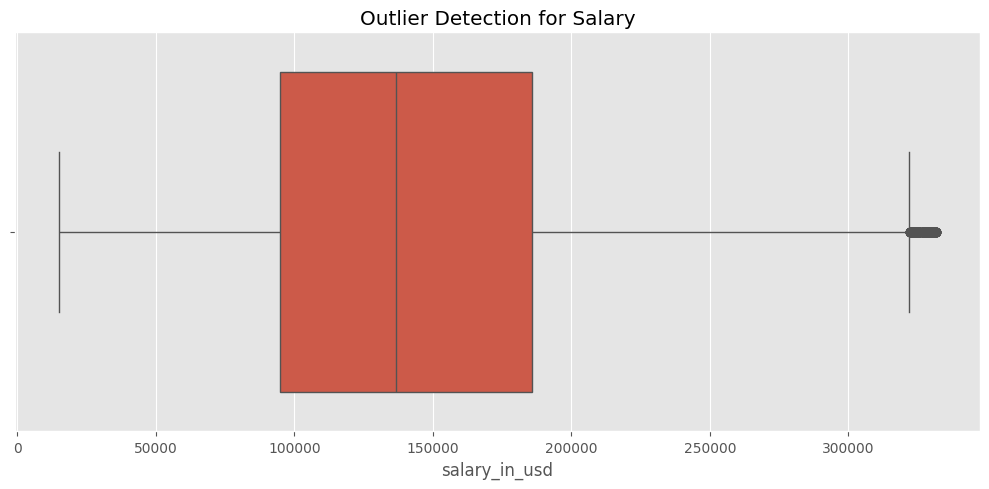

In [33]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x="salary_in_usd"
)

plt.title("Outlier Detection for Salary")

plt.tight_layout()

plt.show()

### Key Insights

Based on the exploratory data analysis, summarize your findings here after reviewing the plots. For example:

- Salary distribution appears to be right-skewed, with a small number of employees earning significantly higher salaries than the majority.
- Senior and executive experience levels generally receive higher salaries compared to entry-level positions.
- Full-time employment is the most common employment type in the dataset.
- Medium-sized companies account for a large proportion of the records.
- Salary distributions vary across company sizes and employment types.
- Outliers are present in the target variable, representing very high salaries. These should be considered carefully before model training.
- Numerical features show varying degrees of correlation, with `salary_in_usd` being the primary target for prediction.

## Notebook Summary: Exploratory Data Analysis (EDA)

In this notebook, we explored the cleaned salary dataset using descriptive statistics and visualizations.

### Tasks Completed

- Imported the required libraries.
- Loaded the cleaned dataset.
- Reviewed the dataset structure.
- Examined the distribution of numerical features.
- Analyzed categorical feature distributions.
- Investigated salary across experience levels, company sizes, and employment types.
- Performed correlation analysis on numerical variables.
- Identified potential outliers in the target variable.

### Conclusion

The exploratory data analysis provided a deeper understanding of the dataset and highlighted patterns that may influence salary prediction. These insights will help guide feature preparation and model development in the next stage of the project.

### Next Notebook

**Notebook 05: Multiple Linear Regression Model Training**